Jumlah baris & kolom: (9994, 21)
=== RINGKASAN OUTLIER (Metode IQR) ===

Sales:
  Batas normal : -271.71 s/d 498.93
  Jumlah outlier: 1167 (11.68% dari total data)

Quantity:
  Batas normal : -2.50 s/d 9.50
  Jumlah outlier: 170 (1.70% dari total data)

Discount:
  Batas normal : -0.30 s/d 0.50
  Jumlah outlier: 856 (8.57% dari total data)

Profit:
  Batas normal : -39.72 s/d 70.82
  Jumlah outlier: 1881 (18.82% dari total data)



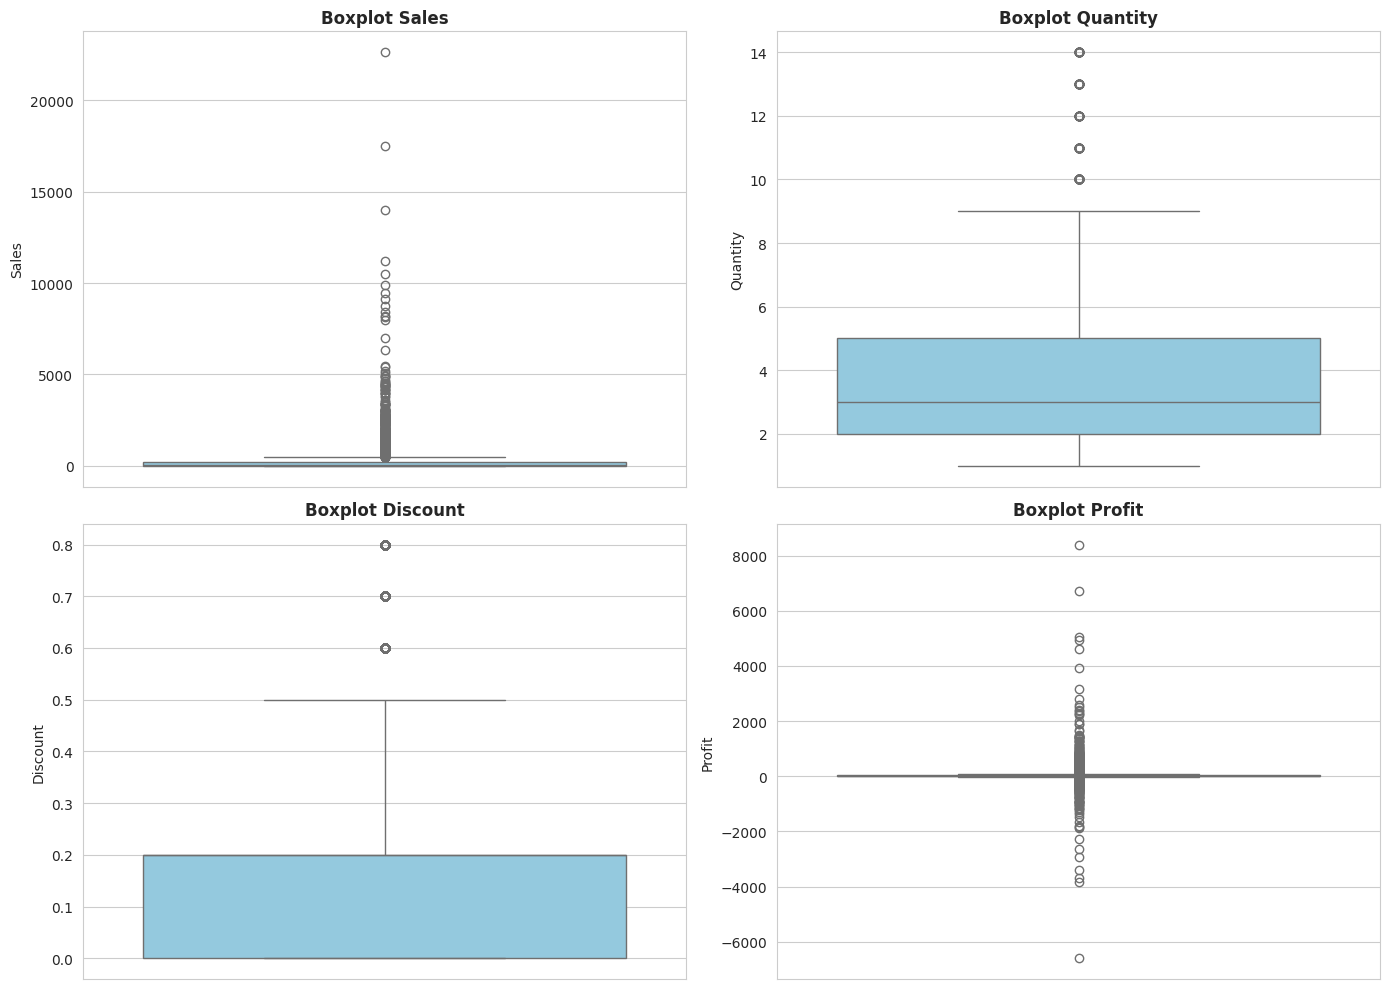

/tmp/ipykernel_868/1857884566.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Category', y='Profit', palette="Set2")


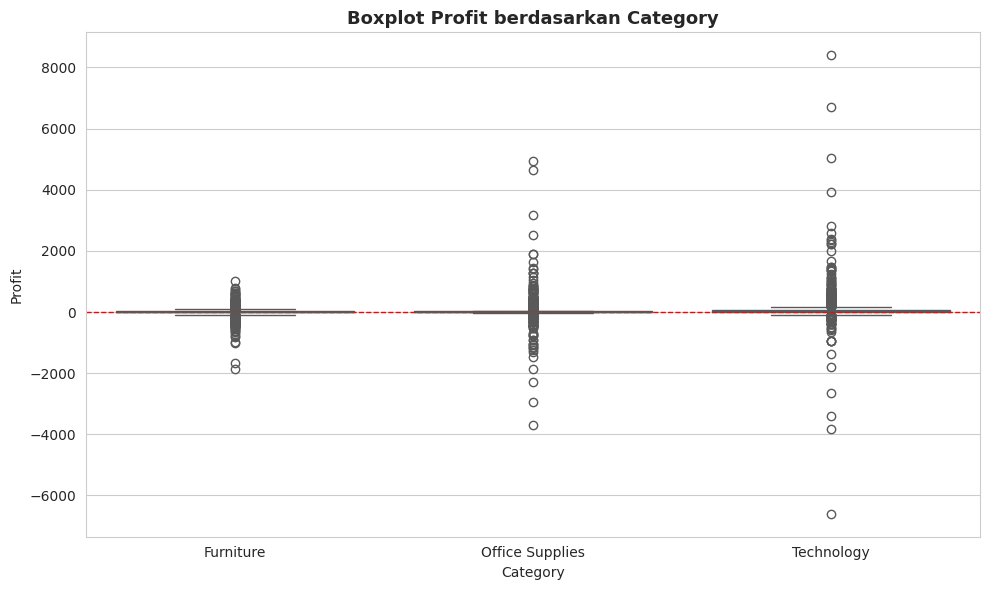

/tmp/ipykernel_868/1857884566.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Sub-Category', y='Sales', palette="Set3")


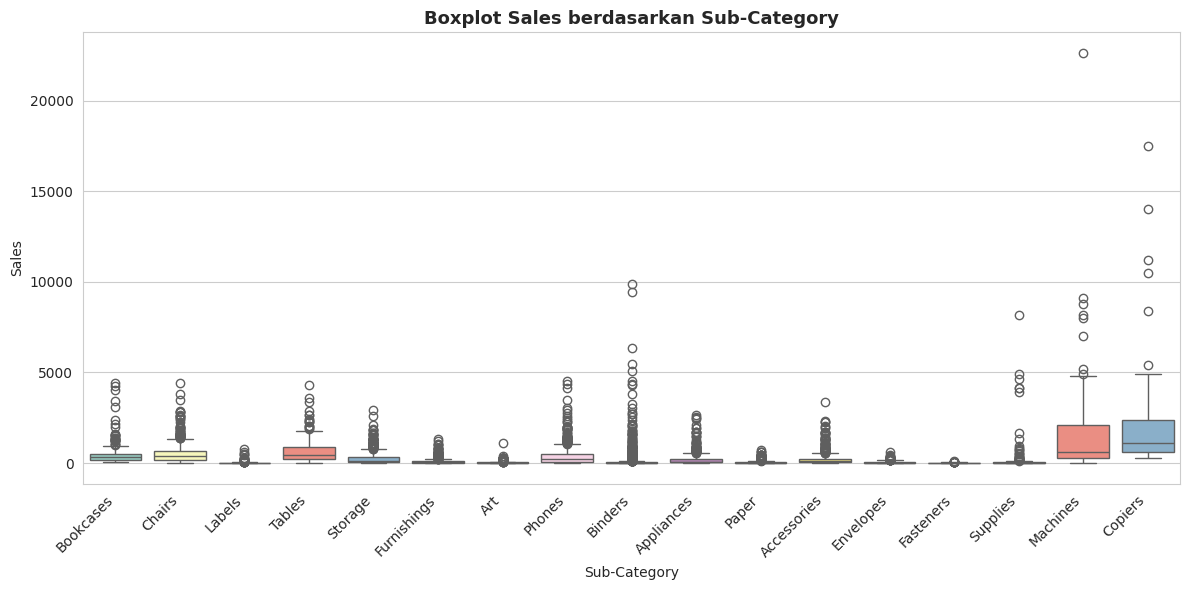

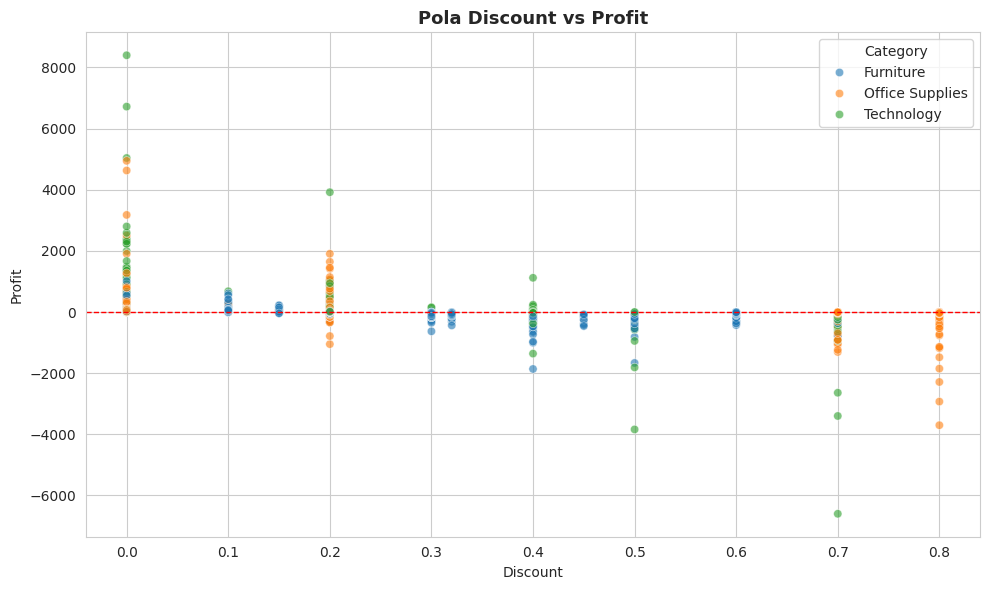

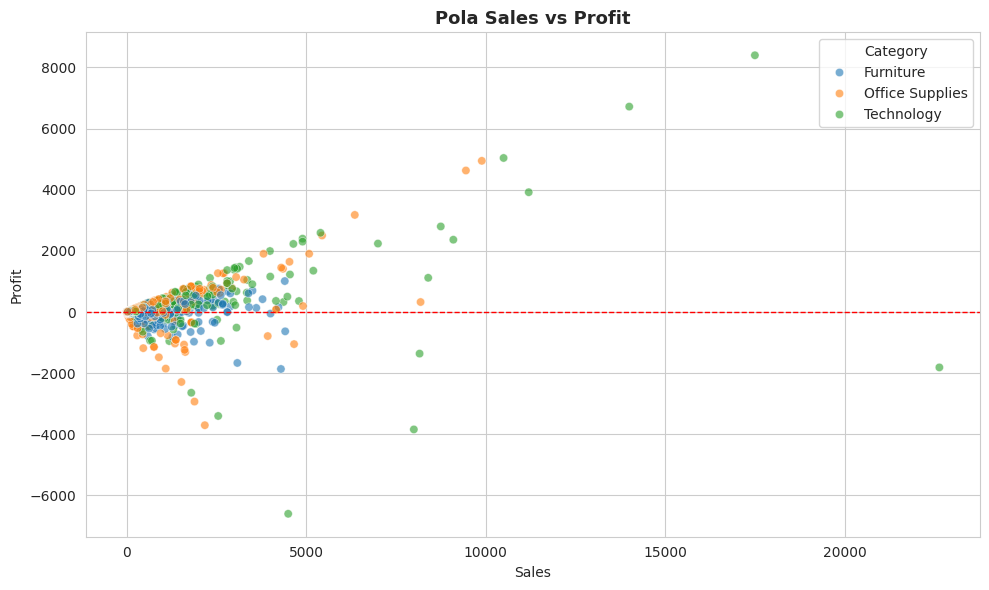

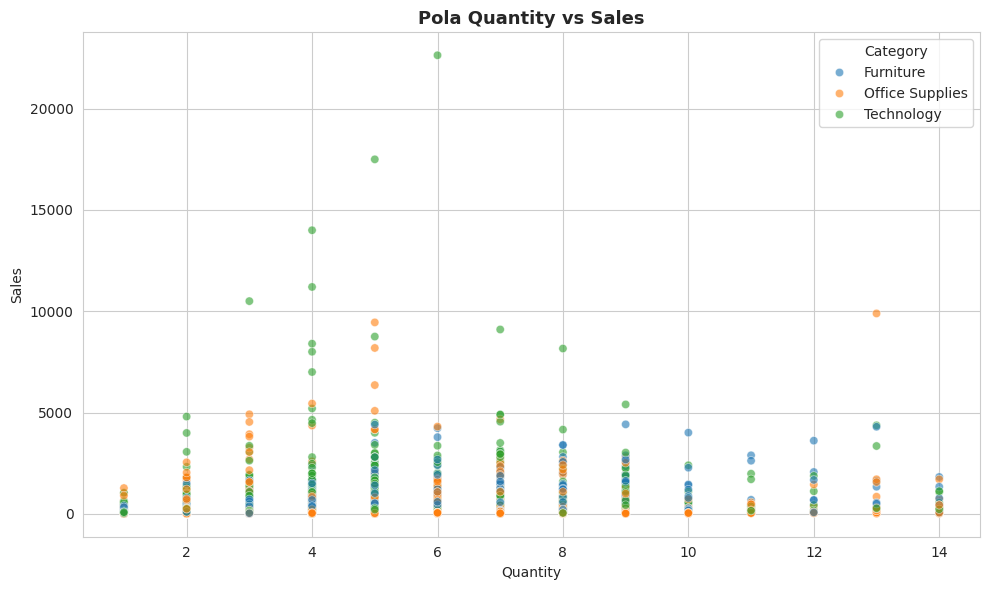

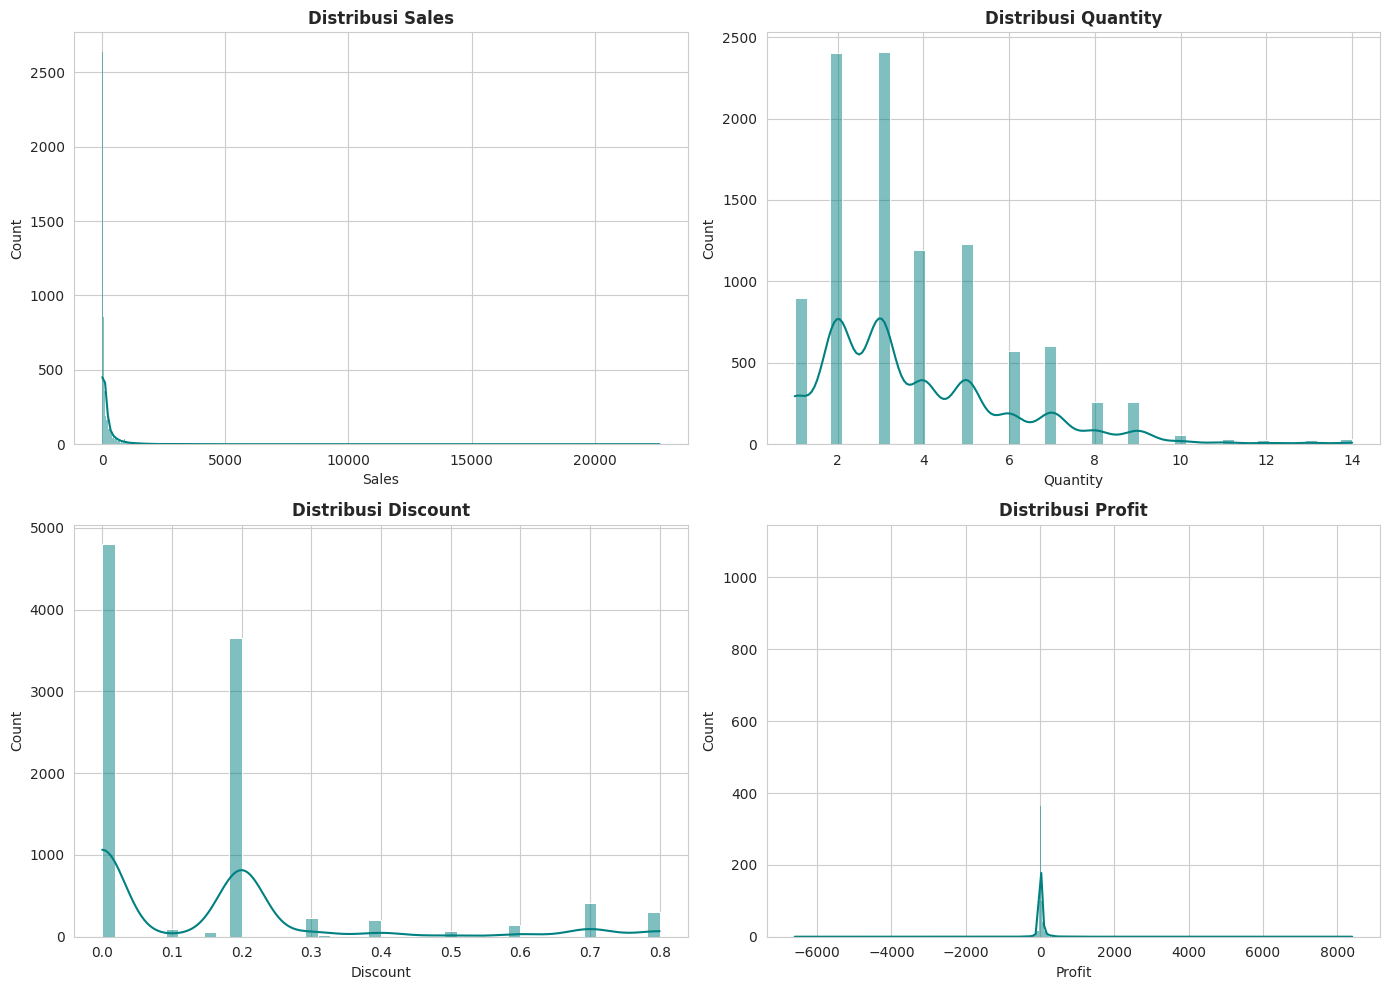

Jumlah transaksi rugi: 1871 (18.72%)
Total kerugian: $-156,131.29
Rata-rata diskon pada transaksi rugi: 48.09%
Rata-rata diskon pada transaksi untung: 8.14%

--- Kerugian berdasarkan Sub-Category ---
Sub-Category
Binders       -38510.4964
Tables        -32412.1483
Machines      -30118.6682
Bookcases     -12152.2060
Chairs         -9880.8413
Appliances     -8629.6412
Phones         -7530.6235
Furnishings    -6490.9134
Storage        -6426.3038
Supplies       -3015.6219
Name: Profit, dtype: float64

--- Kerugian berdasarkan Region ---
Region
Central   -56314.8850
East      -49590.6075
South     -27504.8323
West      -22720.9609
Name: Profit, dtype: float64

=== TABEL RINGKASAN OUTLIER ===
   Variabel  Jumlah_Outlier  Persentase (%)
0     Sales            1167           11.68
1  Quantity             170            1.70
2  Discount             856            8.57
3    Profit            1881           18.82

Semua chart (.png) dan tabel (.csv) tersimpan, siap dipakai untuk laporan 'Outlier 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# --- 2. Load Dataset ---
df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")

# Convert kolom tanggal
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

print("Jumlah baris & kolom:", df.shape)
df.head()


# 3. DETEKSI OUTLIER - METODE IQR
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

numeric_cols = ['Sales', 'Quantity', 'Discount', 'Profit']

print("=== RINGKASAN OUTLIER (Metode IQR) ===\n")
outlier_summary = {}

for col in numeric_cols:
    outliers, lb, ub = detect_outliers_iqr(df, col)
    outlier_summary[col] = len(outliers)
    print(f"{col}:")
    print(f"  Batas normal : {lb:.2f} s/d {ub:.2f}")
    print(f"  Jumlah outlier: {len(outliers)} ({len(outliers)/len(df)*100:.2f}% dari total data)")
    print()

# 4. BOXPLOT - DETEKSI OUTLIER PER VARIABEL

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i], color="skyblue")
    axes[i].set_title(f'Boxplot {col}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('boxplot_outlier_overview.png', dpi=150)
plt.show()


# --- Boxplot Profit per Category (untuk lihat outlier per segmen) ---
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Category', y='Profit', palette="Set2")
plt.title('Boxplot Profit berdasarkan Category', fontsize=13, fontweight='bold')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.tight_layout()
plt.savefig('boxplot_profit_category.png', dpi=150)
plt.show()


# --- Boxplot Sales per Sub-Category (top 10 by count) ---
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Sub-Category', y='Sales', palette="Set3")
plt.xticks(rotation=45, ha='right')
plt.title('Boxplot Sales berdasarkan Sub-Category', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplot_sales_subcategory.png', dpi=150)
plt.show()


# 5. SCATTER PLOT - POLA HUBUNGAN ANTAR VARIABEL
# --- Discount vs Profit (pola paling penting untuk bisnis retail) ---
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category', alpha=0.6)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('Pola Discount vs Profit', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('scatter_discount_profit.png', dpi=150)
plt.show()

# --- Sales vs Profit ---
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Sales', y='Profit', hue='Category', alpha=0.6)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('Pola Sales vs Profit', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('scatter_sales_profit.png', dpi=150)
plt.show()

# --- Quantity vs Sales ---
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Quantity', y='Sales', hue='Category', alpha=0.6)
plt.title('Pola Quantity vs Sales', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('scatter_quantity_sales.png', dpi=150)
plt.show()

# 6. DISTRIBUSI DATA (HISTOGRAM)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color="teal")
    axes[i].set_title(f'Distribusi {col}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('distribusi_histogram.png', dpi=150)
plt.show()


# 7. ANALISIS PENYEBAB OUTLIER PROFIT (NEGATIF)
# Fokus ke transaksi rugi (Profit < 0) sebagai contoh outlier berdampak bisnis
loss_transactions = df[df['Profit'] < 0]

print(f"Jumlah transaksi rugi: {len(loss_transactions)} ({len(loss_transactions)/len(df)*100:.2f}%)")
print(f"Total kerugian: ${loss_transactions['Profit'].sum():,.2f}")
print(f"Rata-rata diskon pada transaksi rugi: {loss_transactions['Discount'].mean():.2%}")
print(f"Rata-rata diskon pada transaksi untung: {df[df['Profit']>=0]['Discount'].mean():.2%}")

print("\n--- Kerugian berdasarkan Sub-Category ---")
print(loss_transactions.groupby('Sub-Category')['Profit'].sum().sort_values().head(10))

print("\n--- Kerugian berdasarkan Region ---")
print(loss_transactions.groupby('Region')['Profit'].sum().sort_values())


# 8. RINGKASAN OUTLIER UNTUK LAPORAN (EXPORT KE EXCEL/CSV)
outlier_report = pd.DataFrame({
    'Variabel': list(outlier_summary.keys()),
    'Jumlah_Outlier': list(outlier_summary.values()),
    'Persentase (%)': [round(v/len(df)*100, 2) for v in outlier_summary.values()]
})
print("\n=== TABEL RINGKASAN OUTLIER ===")
print(outlier_report)

outlier_report.to_csv('outlier_summary.csv', index=False)

top_loss = loss_transactions.sort_values('Profit').head(20)
top_loss.to_csv('top_20_loss_transactions.csv', index=False)

print("\nSemua chart (.png) dan tabel (.csv) tersimpan, siap dipakai untuk laporan 'Outlier Analysis.pdf'")